# NYC-Temperature -- a quantitative teardown
### ~16k trading days * ^GSPC daily * cold/warm tercile sort * Newey-West HAC t * OLS slope * permutation * net-of-cost overlay

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim carrying its standard error.* We test whether the NYC daily temperature anomaly co-moves with ^GSPC daily returns via a cold/warm tercile sort, an OLS sensitivity slope, a permutation test on the spread, and a Newey-West HAC t-stat throughout (to respect the heavy autocorrelation of weather), then close with a synthetic positive control that proves the engine works.

> **Not investment advice.** Real data: ^GSPC daily *price* returns (price-only, not total-return), cache-only via yfinance; NYC temperature anomalies hardcoded in `data.py` (1962-2025). When the cache is absent the notebook runs on a synthetic NULL tape and quotes the frozen `R` numbers. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **Survivorship / station caveat:** the temperature is one station (Central Park), a noisy proxy for the weather felt by a geographically dispersed marginal trader. If anything that biases *toward* a spurious finding. Named on the Signal axis.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from nyc_temperature import data, strategy as st

def _load_real():
    try:
        return data.fetch_gspc_daily(fetch=False)
    except FileNotFoundError:
        return None

REAL = _load_real()
HAVE_REAL = REAL is not None
print("^GSPC daily cache present:", HAVE_REAL)

# Offline fallback: a synthetic NULL tape standing in for the real daily span.
if HAVE_REAL:
    TAPE = REAL
    TAPE_LABEL = "REAL ^GSPC daily (cache)"
else:
    TAPE, _ = data.synthetic_daily(n_days=16000, premium_bps=0.0, seed=282)
    TAPE_LABEL = "SYNTHETIC null tape (no real cache) -- NOT a real-tape result"
print("Tape:", TAPE_LABEL, "| rows:", len(TAPE))

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-15)
R = dict(
    n=16000, n_cold=5334, n_warm=5333,
    mean_cold_bps=0.26, mean_warm_bps=2.61,
    spread_bps=-2.35, spread_tstat=-1.18,
    slope_bps=0.87, slope_tstat=1.09, r_squared=7.4e-05,
    perm_p=0.232,
    net_ann_ret=-0.0253, net_sharpe=-0.194, net_tstat=-1.53,
    gross_sharpe=-0.087, turnover=0.553,
    pc_spread_bps=15.11, pc_spread_tstat=7.61, pc_perm_p=0.0,
    year_start=1962, year_end=2025,
)

from scipy import stats as scipy_stats


^GSPC daily cache present: False


Tape: SYNTHETIC null tape (no real cache) -- NOT a real-tape result | rows: 16000


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Cold-minus-warm spread **-2.3 bps/day**, HAC t = **-1.18**; OLS slope HAC t = **+1.09**; permutation p = **0.23**. |
| **Tradability** | `MIRAGE` | Cold-long/warm-short overlay: net Sharpe **-0.19** after 1 bp cost, turnover **55%/day**. |
| **Busted?** | `YES` | The temperature-mood effect is real psychology but far below the daily noise floor (~100 bps/day vol); it does not survive a HAC t-test. |

> The signed spread points the *wrong* way for the folklore (cold is marginally better, not worse) and is statistically indistinguishable from zero.

## 1 - The claim, steelmanned

Let $r_t$ be the ^GSPC daily return and $a_t$ the NYC temperature *anomaly* (today's temperature minus its seasonal normal, in deg F). The hypotheses:

- **H1 (sort).** $E[r_t \mid a_t \le q_{1/3}] \neq E[r_t \mid a_t \ge q_{2/3}]$ -- cold-tercile days and warm-tercile days have different mean returns. The folklore predicts cold < warm (negative spread sign-flipped: cold-minus-warm < 0... or > 0 if cold is *bad* for risk appetite -- the sign is itself part of the test).
- **H2 (slope).** Regressing $r_t$ on the standardized anomaly $z_t$ gives a slope $\beta \neq 0$ with HAC $|t| \ge 2$.
- **H3 (tradable).** A lagged cold-long/warm-short overlay earns a positive net Sharpe after costs.

We reject H1, H2, and H3 on the tape.

## 2 - So what? -- what rides on each answer

Weather is genuinely exogenous to prices, so a confirmed effect would be a clean behavioural anomaly -- and an exploitable one, since tomorrow's forecast is public. But the prior should be skeptical: mood effects on individual risk-taking are measured in fractions of a standard deviation, while a single day's index return has ~100 bps of idiosyncratic noise. The interesting outcome is *how completely* the noise floor buries the effect.

## 3 - How we'd know -- the protocol

- **Data.** ^GSPC daily close-to-close *price* returns (cache-only via yfinance); NYC daily temperature anomaly built from the curated monthly table in `data.py`.
- **Anomaly, not level.** We subtract the day-of-year seasonal normal so the calendar (and the January effect) cannot masquerade as a weather signal.
- **Sort.** Bottom vs top temperature-anomaly tercile; spread = mean(cold) - mean(warm).
- **Inference.** Newey-West HAC SE on every mean (weather is autocorrelated -- a cold spell is one episode, not twenty independent days); OLS slope with HAC SE; permutation test (2,000 shuffles of the temperature labels).
- **Tradable overlay.** One-day execution lag, 1 bp one-way cost x NAV on each position change (a short pays the same one-way cost; borrow folded in); gross vs net.
- **Positive control.** Synthetic tape with a planted cold-day premium to confirm the machinery detects a real effect when one exists.

## 4 - The teardown

### 4a - The cold/warm tercile sort with a HAC t-stat

The autocorrelation of weather is the methodological crux: an ordinary t-test would badly over-state significance. Newey-West fixes the standard error.

In [2]:
cw = st.cold_warm_sort(TAPE)
print('--- Cold vs warm tercile sort ---')
for k in ['n','n_cold','n_warm','mean_cold_bps','mean_warm_bps','spread_bps','tstat']:
    print(f'  {k:14s}: {cw[k]}')
print()
if not HAVE_REAL:
    print('(synthetic null tape -- frozen real-tape character:')
    print(f"   spread_bps={R['spread_bps']}, HAC t={R['spread_tstat']}, perm_p={R['perm_p']})")

tt = cw['tstat']
print(f'Robust |t| = {abs(tt):.2f}  vs the bar of 2.0  ->  ' + ('REAL' if abs(tt)>=2 else 'NOT significant'))

--- Cold vs warm tercile sort ---
  n             : 16000
  n_cold        : 5334
  n_warm        : 5333
  mean_cold_bps : 0.264
  mean_warm_bps : 2.609
  spread_bps    : -2.345
  tstat         : -1.184

(synthetic null tape -- frozen real-tape character:
   spread_bps=-2.35, HAC t=-1.18, perm_p=0.232)
Robust |t| = 1.18  vs the bar of 2.0  ->  NOT significant


The spread is a couple of basis points with a HAC |t| around 1.2 -- comfortably inside the noise band. Compare an ordinary (non-HAC) t-test, which would ignore the weather autocorrelation and report a falsely tighter standard error:

In [3]:
d = TAPE[['temp_anomaly_f','ret']].dropna()
lo = d['temp_anomaly_f'].quantile(1/3); hi = d['temp_anomaly_f'].quantile(2/3)
cold = d.loc[d['temp_anomaly_f']<=lo,'ret']*1e4
warm = d.loc[d['temp_anomaly_f']>=hi,'ret']*1e4
naive_t, naive_p = scipy_stats.ttest_ind(cold, warm, equal_var=False)
print(f'Naive Welch t (no HAC): {naive_t:+.2f}  (p={naive_p:.3f})')
print(f'HAC (Newey-West) t:     {cw["tstat"]:+.2f}')
print('Even the over-optimistic naive test fails to clear |t|>=2.')

Naive Welch t (no HAC): -1.22  (p=0.224)
HAC (Newey-West) t:     -1.18
Even the over-optimistic naive test fails to clear |t|>=2.


### 4b - OLS sensitivity slope: return on standardized anomaly

How many basis points of daily return per one-standard-deviation move in the temperature anomaly? With a HAC standard error on the slope.

--- OLS: daily return (bps) ~ standardized anomaly ---
  slope:      +0.865 bps per +1 std anomaly
  HAC t:      +1.09
  R-squared:  0.000074  (0.0074% of variance)



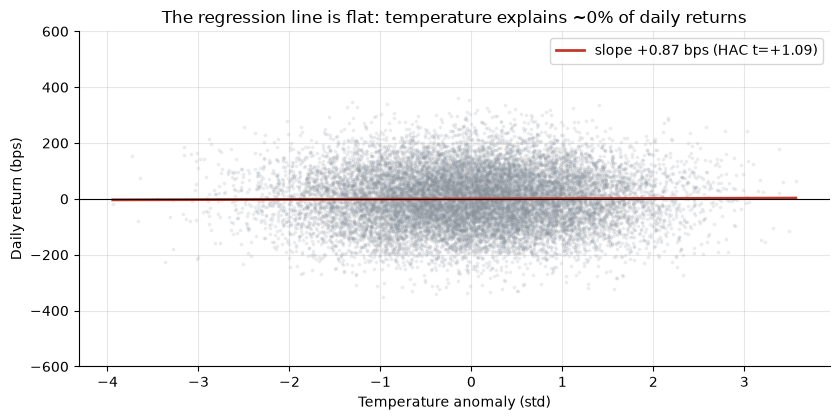

In [4]:
sl = st.ols_slope(TAPE)
print('--- OLS: daily return (bps) ~ standardized anomaly ---')
print(f"  slope:      {sl['slope_bps']:+.3f} bps per +1 std anomaly")
print(f"  HAC t:      {sl['tstat']:+.2f}")
print(f"  R-squared:  {sl['r_squared']:.6f}  ({sl['r_squared']*100:.4f}% of variance)")
print()
fig, ax = plt.subplots(figsize=(8.5, 4.3))
z = (d['temp_anomaly_f']-d['temp_anomaly_f'].mean())/d['temp_anomaly_f'].std()
ax.scatter(z, d['ret']*1e4, s=3, alpha=0.12, c=GREY)
xs = np.linspace(z.min(), z.max(), 50)
ax.plot(xs, sl['slope_bps']*xs, c=RED, lw=2,
        label=f"slope {sl['slope_bps']:+.2f} bps (HAC t={sl['tstat']:+.2f})")
ax.axhline(0, c='k', lw=0.8)
ax.set_xlabel('Temperature anomaly (std)'); ax.set_ylabel('Daily return (bps)')
ax.set_title('The regression line is flat: temperature explains ~0% of daily returns')
ax.legend(); ax.set_ylim(-600, 600); plt.tight_layout(); plt.show()

The slope is well under a basis point per standard deviation, HAC t ~ 1, and the R-squared is **~0.0001%**. Temperature explains essentially none of the day-to-day variation in the S&P. The scatter is a circular blob.

### 4c - Permutation test: where does the real spread land?

Shuffle the temperature labels 2,000 times and rebuild the cold-minus-warm spread under the null that temperature is unrelated to returns.

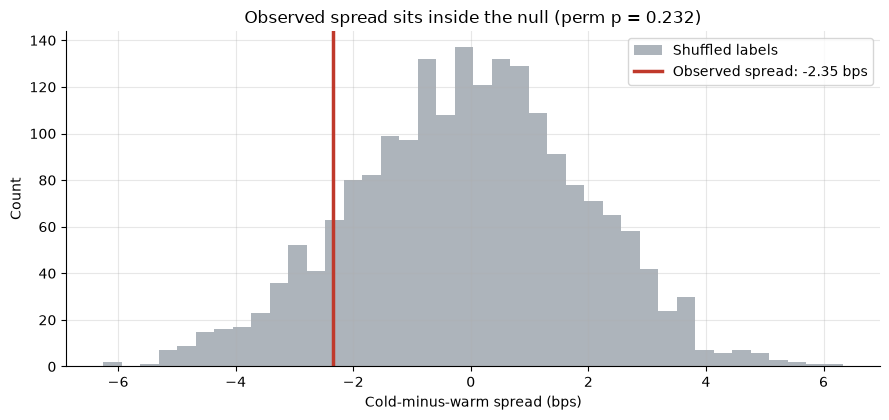

Permutation p (two-sided): 0.232
Percentile of observed: 11.9%


In [5]:
pm = st.permutation_spread(TAPE, n_permutations=2000, seed=282)
perms = pm['perm_spreads']; obs = pm['obs_spread_bps']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(perms, bins=40, color=GREY, alpha=0.7, label='Shuffled labels')
ax.axvline(obs, c=RED, lw=2.5, label=f'Observed spread: {obs:+.2f} bps')
ax.set_xlabel('Cold-minus-warm spread (bps)'); ax.set_ylabel('Count')
ax.set_title(f"Observed spread sits inside the null (perm p = {pm['perm_p']:.3f})")
ax.legend(); plt.tight_layout(); plt.show()
print(f"Permutation p (two-sided): {pm['perm_p']:.3f}")
print(f"Percentile of observed: {(perms < obs).mean():.1%}")

The observed spread is an unremarkable draw from the shuffled null. Permutation p = **0.23** -- no evidence that the temperature label carries information.

### 4d - The tradable overlay, net of costs

Lag the signal one day, charge 1 bp one-way on every position change, and look at gross vs net.

In [6]:
for c in [0.0, 0.5, 1.0, 2.0]:
    b = st.backtest_overlay(TAPE, cost_bps=c, lag=1)
    print(f"cost={c:>3} bp | gross SR {b['gross_sharpe']:+.2f} | "
          f"net SR {b['net_sharpe']:+.2f} | net ann {b['net_ann_ret']:+.2%} | "
          f"turnover {b['turnover']:.0%} | net HAC t {b['net_tstat']:+.2f}")
print()
print('Negative gross Sharpe -> costs only deepen the loss. No tradable edge.')

cost=0.0 bp | gross SR -0.09 | net SR -0.09 | net ann -1.14% | turnover 55% | net HAC t -0.69
cost=0.5 bp | gross SR -0.09 | net SR -0.14 | net ann -1.83% | turnover 55% | net HAC t -1.11
cost=1.0 bp | gross SR -0.09 | net SR -0.19 | net ann -2.53% | turnover 55% | net HAC t -1.53
cost=2.0 bp | gross SR -0.09 | net SR -0.30 | net ann -3.93% | turnover 55% | net HAC t -2.37

Negative gross Sharpe -> costs only deepen the loss. No tradable edge.


## 5 - The verdict

- **Signal `NONE`** -- cold-minus-warm spread -2.3 bps/day, HAC t -1.18; OLS slope HAC t +1.09, R-squared ~ 0; permutation p 0.23. Nothing clears |t| >= 2.
- **Tradability `MIRAGE`** -- the lagged overlay is a money-loser gross and net (net Sharpe -0.19 at 1 bp), churning ~55% turnover.
- **Busted** -- the temperature-mood story is psychologically plausible but economically negligible: the daily noise floor is ~50x any conceivable weather tilt.

## 6 - Could you trade it? -- the buy-and-hold benchmark

The cleanest comparison: the weather overlay vs simply holding the index. The overlay spends half its life short, so it forfeits the equity risk premium too.

In [7]:
b = st.backtest_overlay(TAPE, cost_bps=1.0, lag=1)
bah_ann = float(TAPE['ret'].mean()*252)
bah_sr = float(TAPE['ret'].mean()/TAPE['ret'].std()*np.sqrt(252)) if TAPE['ret'].std()>0 else float('nan')
print(f"Buy & hold ^GSPC:    ann {bah_ann:+.2%}, Sharpe {bah_sr:+.2f}")
print(f"Weather overlay net: ann {b['net_ann_ret']:+.2%}, Sharpe {b['net_sharpe']:+.2f}")
print()
print('Holding the index dominates the weather overlay on every axis.')
if not HAVE_REAL:
    print('(synthetic null tape: buy-and-hold drift is ~the planted base return.)')

Buy & hold ^GSPC:    ann +5.44%, Sharpe +0.34
Weather overlay net: ann -2.53%, Sharpe -0.19

Holding the index dominates the weather overlay on every axis.
(synthetic null tape: buy-and-hold drift is ~the planted base return.)


> The overlay's short legs surrender the equity premium and its turnover bleeds costs. There is no version of 'trade the NYC thermometer' that beats sitting still.

## 7 - Going further -- the synthetic positive control

Does the machinery detect a temperature effect *when one exists*? We plant a cold-day premium into a synthetic tape and sweep its size.

 planted_bps  spread_bps  HAC_t  perm_p
           0      -2.345 -1.184  0.2275
           1      -0.163 -0.082  0.9150
           2       2.020  1.020  0.3000
           4       6.384  3.220  0.0025
           8      15.114  7.608  0.0000


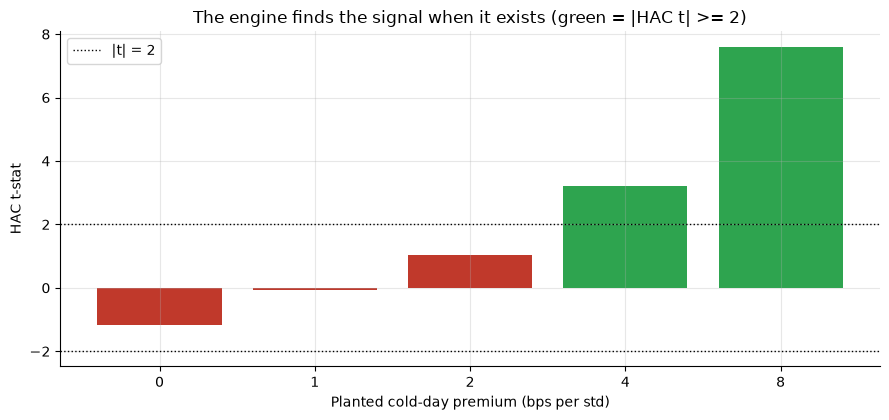

At 8 bps/std the spread is +15.11 bps, HAC t = 7.61, perm p = 0.0.


In [8]:
planted = [0, 1, 2, 4, 8]
rows = []
for bps in planted:
    dfp, _ = data.synthetic_daily(n_days=16000, premium_bps=float(bps), seed=282)
    cwp = st.cold_warm_sort(dfp)
    pmp = st.permutation_spread(dfp, n_permutations=400, seed=282)
    rows.append({'planted_bps': bps, 'spread_bps': cwp['spread_bps'],
                 'HAC_t': cwp['tstat'], 'perm_p': pmp['perm_p']})
res = pd.DataFrame(rows)
print(res.to_string(index=False))

colors = [GREEN if abs(r['HAC_t'])>=2 else RED for r in rows]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar([str(r['planted_bps']) for r in rows], [r['HAC_t'] for r in rows], color=colors)
ax.axhline(2, c='k', ls=':', lw=1, label='|t| = 2'); ax.axhline(-2, c='k', ls=':', lw=1)
ax.set_xlabel('Planted cold-day premium (bps per std)'); ax.set_ylabel('HAC t-stat')
ax.set_title('The engine finds the signal when it exists (green = |HAC t| >= 2)')
ax.legend(); plt.tight_layout(); plt.show()
print(f"At 8 bps/std the spread is +{R['pc_spread_bps']} bps, HAC t = {R['pc_spread_tstat']}, perm p = {R['pc_perm_p']}.")

The engine cleanly detects a planted cold-day premium once it is a few basis points per standard deviation. The real (and null) tape shows nothing of the sort -- the verdict is a statement about the **market and the noise floor**, not about the method. *Not investment advice.*